Tratamento de Dados - Aula 06

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import smtplib ##Biblioteca pra acessar o email
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from email.mime.application import MIMEApplication
import psycopg2 ##Biblioteca que permite acessar o banco
from sqlalchemy import create_engine ##Biblioteca que permite que o python leia o Sql

In [3]:
#Dados de conexão
host = 'postgresql-datadt.alwaysdata.net' ##Onde o servidor está hospedado
database = 'datadt_digital_corporativo'
user = 'datadt_data_analytics'
password = 'DataAnalytics$100'

In [4]:
#Dados que foram "puxados" do banco
sql = ''' 
    select date_part('YEAR', nf.data_venda) as ano, 
    c.descricao as categoria_produto, 
    sum(inf.valor_venda_real) as valor_venda
    from vendas.nota_fiscal nf
    join vendas.item_nota_fiscal inf on inf.id_nota_fiscal = nf.id
    join vendas.produto p ON p.id = inf.id_produto
    join vendas.categoria c ON c.id = p.id_categoria
    group by date_part('YEAR', nf.data_venda), c.descricao
    order by ano, categoria_produto
'''

# Criar engine de conexão
engine = create_engine(f'postgresql://{user}:{password}@{host}/{database}')

#Executar a consulta na váriavel SQL e criar o Dataframe
df = pd.read_sql(sql, engine)

In [5]:
df

,ano,categoria_produto,valor_venda
0,2015.0,CELULARES,2634357.00
1,2015.0,DVDS,219527.00
2,2015.0,ELETRODOMESTICOS,3302626.00
3,2015.0,GAMES,671046.00
4,2015.0,INFORMATICA,9395532.00
...,...,...,...
103,2026.0,INFORMATICA,18650028.51
104,2026.0,LIVROS,293576.77
105,2026.0,MOVEIS,3223141.21
106,2026.0,PASSAGENS,5923557.62


Tratamento para a criação de uma variável da categoria

In [8]:
df_categoria = pd.read_csv("../Input/categorias_valores.csv")

In [9]:
df_categoria.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Categoria  9 non-null      str    
 1   Valor      9 non-null      float64
dtypes: float64(1), str(1)
memory usage: 276.0 bytes


In [10]:
df['categoria_produto'].unique()

<StringArray>
[       'CELULARES',             'DVDS', 'ELETRODOMESTICOS',
            'GAMES',      'INFORMATICA',           'LIVROS',
           'MOVEIS',        'PASSAGENS',       'TV E AUDIO']
Length: 9, dtype: str

In [11]:
#Renomeando a coluna categoria
df_categoria = df_categoria.rename(columns={'Categoria': "categoria_produto"})

In [ ]:
df_categoria #A coluna valor está em percentual

,categoria_produto,Valor
0,INFORMATICA,1.30
1,ELETRODOMESTICOS,1.15
2,LIVROS,2.10
3,TV E AUDIO,1.75
4,GAMES,3.50
5,DVDS,3.50
6,MOVEIS,1.12
7,CELULARES,2.15
8,PASSAGENS,1.54


In [12]:
#Fazendo a ligação das tabelas
df_combinado = pd.merge(df, df_categoria, on = 'categoria_produto', how='left')

In [13]:
df_combinado

,ano,categoria_produto,valor_venda,Valor
0,2015.0,CELULARES,2634357.00,2.15
1,2015.0,DVDS,219527.00,3.50
2,2015.0,ELETRODOMESTICOS,3302626.00,1.15
3,2015.0,GAMES,671046.00,3.50
4,2015.0,INFORMATICA,9395532.00,1.30
...,...,...,...,...
103,2026.0,INFORMATICA,18650028.51,1.30
104,2026.0,LIVROS,293576.77,2.10
105,2026.0,MOVEIS,3223141.21,1.12
106,2026.0,PASSAGENS,5923557.62,1.54


In [14]:
df_combinado = df_combinado.rename(columns={'Valor': "percentual_aumento"})

In [15]:
df_combinado

,ano,categoria_produto,valor_venda,percentual_aumento
0,2015.0,CELULARES,2634357.00,2.15
1,2015.0,DVDS,219527.00,3.50
2,2015.0,ELETRODOMESTICOS,3302626.00,1.15
3,2015.0,GAMES,671046.00,3.50
4,2015.0,INFORMATICA,9395532.00,1.30
...,...,...,...,...
103,2026.0,INFORMATICA,18650028.51,1.30
104,2026.0,LIVROS,293576.77,2.10
105,2026.0,MOVEIS,3223141.21,1.12
106,2026.0,PASSAGENS,5923557.62,1.54


In [16]:
df_combinado = df_combinado.rename(columns={'Valor': 'percentual_aumento'})

In [ ]:
#Cálculo do percentual do aumento sobre o valor de venda criando uma nova coluna
df_combinado['novo_valor'] = df_combinado['valor_venda'] * (1 + (df_combinado['percentual_aumento']/100))

In [18]:
#Arrendondamento de duas casas decimáis
df_combinado['novo_valor'] = df_combinado['novo_valor'].round(2)

In [16]:
df_combinado.columns

Index(['ano', 'categoria_produto', 'valor_venda', 'percentual_aumento',
       'novo_valor'],
      dtype='str')

In [ ]:
#Exclusão da coluna ano
df_combinado[['categoria_produto', 'valor_venda', 'percentual_aumento', 'novo_valor']]

,categoria_produto,valor_venda,percentual_aumento,novo_valor
0,CELULARES,2634357.00,2.15,2690995.68
1,DVDS,219527.00,3.50,227210.44
2,ELETRODOMESTICOS,3302626.00,1.15,3340606.20
3,GAMES,671046.00,3.50,694532.61
4,INFORMATICA,9395532.00,1.30,9517673.92
...,...,...,...,...
103,INFORMATICA,13730687.26,1.30,13909186.19
104,LIVROS,216674.42,2.10,221224.58
105,MOVEIS,2336379.79,1.12,2362547.24
106,PASSAGENS,4395138.74,1.54,4462823.88


In [20]:
#Agregação da soma das colunas categoria_produto e percentual_aumento agregado pela soma da valor_venda e novo_valor 
# juntamente com uma nova indexação 
df_resultado = df_combinado.groupby(
    ['categoria_produto', 'percentual_aumento']
).agg({
        'valor_venda': 'sum', 
        'novo_valor': 'sum'
}).reset_index()

In [21]:
df_resultado

,categoria_produto,percentual_aumento,valor_venda,novo_valor
0,CELULARES,2.15,8.000700e+07,8.172715e+07
1,DVDS,3.50,6.900979e+06,7.142514e+06
2,ELETRODOMESTICOS,1.15,1.039282e+08,1.051234e+08
3,GAMES,3.50,1.982874e+07,2.052275e+07
4,INFORMATICA,1.30,2.798068e+08,2.834443e+08
5,LIVROS,2.10,4.322368e+06,4.413138e+06
6,MOVEIS,1.12,4.940123e+07,4.995452e+07
7,PASSAGENS,1.54,9.220556e+07,9.362552e+07
8,TV E AUDIO,1.75,2.168334e+08,2.206280e+08


In [ ]:
#Exibir números float com duas casas decimais
pd.set_option('display.float_format', '{:.2f}'.format )

In [24]:
df_resultado

,categoria_produto,percentual_aumento,valor_venda,novo_valor
0,CELULARES,2.15,80007000.21,81727150.72
1,DVDS,3.50,6900979.30,7142513.57
2,ELETRODOMESTICOS,1.15,103928214.47,105123388.94
3,GAMES,3.50,19828744.64,20522750.71
4,INFORMATICA,1.30,279806799.21,283444287.61
5,LIVROS,2.10,4322368.38,4413138.11
6,MOVEIS,1.12,49401226.58,49954520.32
7,PASSAGENS,1.54,92205557.30,93625522.88
8,TV E AUDIO,1.75,216833425.45,220628010.40


In [25]:
# Criando o gráfico de barras duplo
categorias = df_resultado['categoria_produto'].unique()
bar_width = 0.35
index = np.arange(len(categorias))



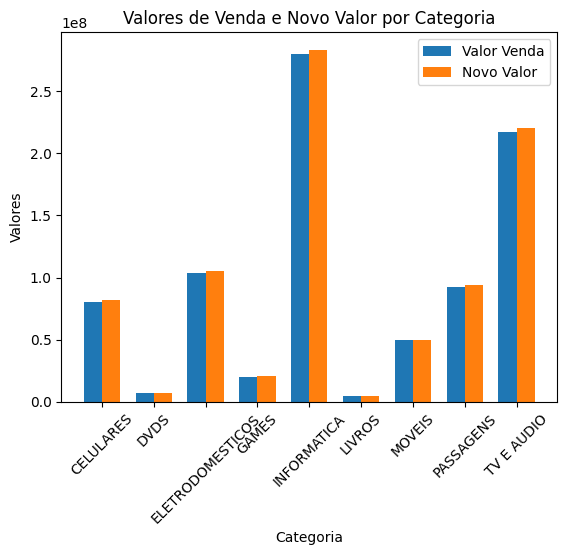

In [26]:
plt.bar(index, df_resultado['valor_venda'], width=bar_width, label='Valor Venda')
plt.bar(index + bar_width, df_resultado['novo_valor'], width=bar_width, label='Novo Valor')

# Configurando o eixo x
plt.xlabel('Categoria')
plt.ylabel('Valores')
plt.title('Valores de Venda e Novo Valor por Categoria')
plt.xticks(index + bar_width / 2, categorias, rotation=45)
plt.legend()

# Exibindo o gráfico
plt.show()

In [27]:
#função usada para criar envios de e-mail com python
def enviar_email(df,grafico):
    #configuração do e-mail
    remetente ='gabrielmesk@gmail.com'
    senha ='rpwc qqyi dstp yyzf'
    destinatario ='gabrielmesquita_olive@hotmail.com'

    #configuração do servidor SMTP
    servidor_smtp = 'smtp.gmail.com'
    porta_smtp = 587

    #Criar o corpo do e-mail
    mensagem = MIMEMultipart()
    mensagem['From'] = remetente
    mensagem['To'] = destinatario
    mensagem['Subject'] = 'Relatório de Dados e Gráfico.'

    #Adicionado informações no corpo do e-mail
    corpo_email = 'Arquivo em anexo. Veja o relatório e o gráfico'
    mensagem.attach(MIMEText(corpo_email, 'plain'))

    #Adicionando o DataFrame como anexo
    df_csv = df.to_csv(index = False)
    attachment = MIMEText(df_csv)
    attachment.add_header('Content-Disposition', 'attachment', filename= 'dados.csv')
    mensagem.attach(attachment)

    #Salvando como uma imagem
    grafico.savefig('grafico.png')
    grafico.close()

    #adicionando o grafico como anexo
    with open('grafico.png', 'rb') as img:
        attachment = MIMEApplication(img.read(), _subtype = 'png')
        attachment.add_header('Content-Disposition', 'attachment', filename='grafico.png')
        mensagem.attach(attachment)

    #Conectando ao servidor SMTP e enviando o email
    with smtplib.SMTP(servidor_smtp, porta_smtp) as server:
        server.starttls()
        server.login(remetente, senha)
        server.sendmail(remetente, destinatario, mensagem.as_string())

In [28]:
import smtplib
from email.mime.text import MIMEText

remetente = 'gabrielmesk@gmail.com'
senha = 'rpwc qqyi dstp yyzf'
destinatario = 'gabrielmesquita_olive@hotmail.com'

mensagem = MIMEText('Teste de envio de e-mail')
mensagem['Subject'] = 'Teste Python'
mensagem['From'] = remetente
mensagem['To'] = destinatario

try:

    with smtplib.SMTP('smtp.gmail.com', 587) as server:

        print('Conectando...')

        server.starttls()

        print('Fazendo login...')

        server.login(remetente, senha)

        print('Enviando...')

        server.sendmail(
            remetente,
            destinatario,
            mensagem.as_string()
        )

        print('E-mail enviado com sucesso!')

except Exception as erro:

    print('Erro encontrado:')
    print(erro)

Conectando...
Fazendo login...
Enviando...
E-mail enviado com sucesso!
